# CTA VAI — Modern Publication Design

This notebook keeps the **same structure** as your current figure:

- A–E conditions on the x-axis
- raw image-level points
- faint matched-image trajectories
- mean ± 95% CI
- connected condition means
- FDR-corrected significance bracket

The change is purely **visual design**: cleaner hierarchy, softer grid, modern typography, better spacing, subtle emphasis, and more polished annotations.

It uses:
- `matplotlib`
- `numpy`
- `pandas`
- `scipy`
- `matplotlib.patheffects`
- `matplotlib.patches`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from scipy import stats
from matplotlib.patches import FancyBboxPatch


## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"
POSTHOC_CSV = "data/A_to_E_repeated_measures_posthoc.csv"

AOI = "CTA"
METRIC = "VAI (%)"

CONDITION_ORDER = ["A", "B", "C", "D", "E"]

# Comparisons to annotate if significant
SIGNIFICANCE_PAIRS = [
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("C", "E"),
]

SHOW_MATCHED_LINES = True
SHOW_MEAN_LABELS = True

OUTPUT_PNG = "CTA_VAI_modern_publication.png"
OUTPUT_PDF = "CTA_VAI_modern_publication.pdf"

RANDOM_SEED = 42


## 2. Load data

In [3]:
for f in [LONG_CSV, POSTHOC_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(f"Could not find {f}")

long_df = pd.read_csv(LONG_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)

for frame in [long_df, posthoc]:
    frame.columns = [str(c).replace("**", "").strip() for c in frame.columns]

focus = long_df[
    (long_df["AOI"] == AOI)
    & (long_df["metric"] == METRIC)
    & (long_df["condition"].isin(CONDITION_ORDER))
].copy()

focus["value"] = pd.to_numeric(focus["value"], errors="coerce")
focus = focus.dropna(subset=["value"])

pivot = (
    focus.pivot(index="Img", columns="condition", values="value")
         .reindex(columns=CONDITION_ORDER)
)

print("Unique images:", focus["Img"].nunique())
print("Complete matched images:", len(pivot.dropna()))


Unique images: 20
Complete matched images: 17


## 3. Means and 95% confidence intervals

In [4]:
summary_rows = []

for cond in CONDITION_ORDER:
    vals = (
        focus.loc[focus["condition"] == cond, "value"]
        .dropna()
        .astype(float)
        .values
    )

    n = len(vals)
    mean = np.mean(vals)
    sd = np.std(vals, ddof=1)

    if n > 1:
        se = sd / np.sqrt(n)
        tcrit = stats.t.ppf(0.975, df=n - 1)
        ci = tcrit * se
    else:
        ci = np.nan

    summary_rows.append({
        "condition": cond,
        "n": n,
        "mean": mean,
        "sd": sd,
        "ci95": ci,
        "lower": mean - ci if np.isfinite(ci) else np.nan,
        "upper": mean + ci if np.isfinite(ci) else np.nan,
    })

summary = pd.DataFrame(summary_rows)
summary


,condition,n,mean,sd,ci95,lower,upper
0,A,20,19.265000,15.686074,7.341309,11.923691,26.606309
1,B,20,26.680000,14.740799,6.898906,19.781094,33.578906
2,C,20,33.870000,13.099421,6.130718,27.739282,40.000718
3,D,19,24.421053,15.817310,7.623700,16.797353,32.044752
4,E,18,28.222222,13.510630,6.718678,21.503544,34.940900


## 4. Post-hoc helper

In [5]:
def get_pair_row(g1, g2):
    mask = (
        (posthoc["AOI"] == AOI)
        & (posthoc["metric"] == METRIC)
        & (
            ((posthoc["group1"] == g1) & (posthoc["group2"] == g2))
            | ((posthoc["group1"] == g2) & (posthoc["group2"] == g1))
        )
    )

    rows = posthoc.loc[mask]
    return None if len(rows) == 0 else rows.iloc[0]


def format_q(q):
    if pd.isna(q):
        return ""
    if q < 0.001:
        return "q < .001"
    return f"q = {q:.3f}"


## 5. Modern publication figure

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


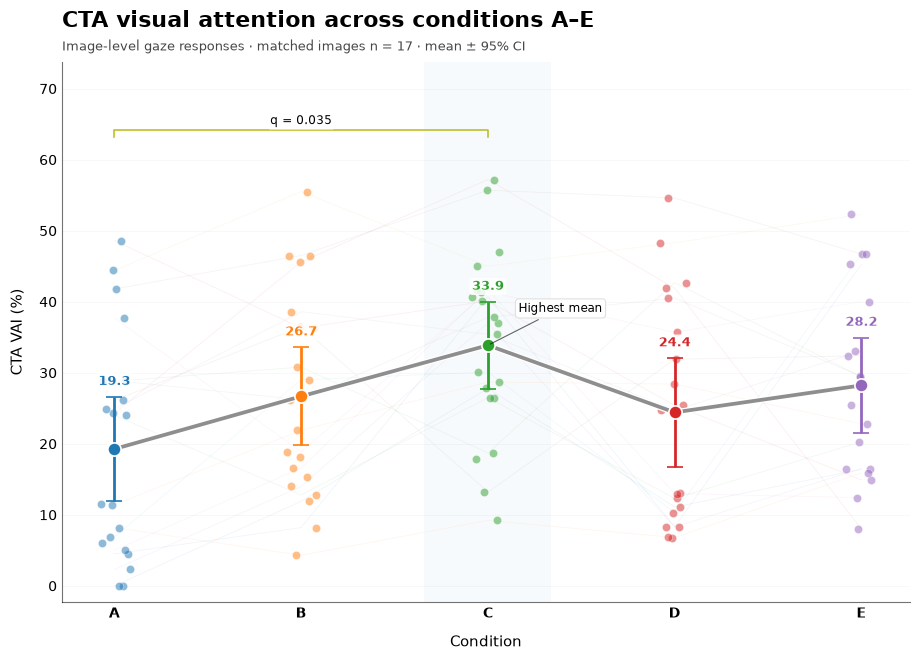

Saved: CTA_VAI_modern_publication.png
Saved: CTA_VAI_modern_publication.pdf


In [6]:
# ---------------------------------------------------------
# DESIGN SETUP
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
})

fig, ax = plt.subplots(figsize=(9.3, 6.7))

x_positions = {c: i for i, c in enumerate(CONDITION_ORDER)}

# Use the active Matplotlib cycle instead of hard-coded colors
cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if len(cycle_colors) < len(CONDITION_ORDER):
    cycle_colors = [f"C{i}" for i in range(len(CONDITION_ORDER))]

condition_colors = {
    c: cycle_colors[i]
    for i, c in enumerate(CONDITION_ORDER)
}

# ---------------------------------------------------------
# SOFT BACKGROUND EMPHASIS FOR CONDITION C
# ---------------------------------------------------------
c_x = x_positions["C"]

ax.axvspan(
    c_x - 0.34,
    c_x + 0.34,
    alpha=0.035,
    zorder=0
)

# ---------------------------------------------------------
# MATCHED-IMAGE TRAJECTORIES
# ---------------------------------------------------------
if SHOW_MATCHED_LINES:
    complete = pivot.dropna()

    for _, row in complete.iterrows():
        ax.plot(
            np.arange(len(CONDITION_ORDER)),
            row[CONDITION_ORDER].astype(float).values,
            linewidth=0.6,
            alpha=0.07,
            zorder=1
        )

# ---------------------------------------------------------
# RAW IMAGE-LEVEL POINTS
# ---------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED)

for cond in CONDITION_ORDER:
    vals = (
        focus.loc[focus["condition"] == cond, "value"]
        .dropna()
        .astype(float)
        .values
    )

    x0 = x_positions[cond]

    jitter = rng.uniform(
        -0.085,
        0.085,
        size=len(vals)
    )

    ax.scatter(
        np.full(len(vals), x0) + jitter,
        vals,
        s=35,
        alpha=0.50,
        color=condition_colors[cond],
        edgecolors="white",
        linewidths=0.45,
        zorder=3
    )

# ---------------------------------------------------------
# MEAN LINE
# ---------------------------------------------------------
mean_values = [
    summary.loc[summary["condition"] == c, "mean"].iloc[0]
    for c in CONDITION_ORDER
]

ax.plot(
    np.arange(len(CONDITION_ORDER)),
    mean_values,
    linewidth=2.7,
    alpha=0.88,
    zorder=4,
    path_effects=[
        pe.Stroke(linewidth=4.5, foreground="white"),
        pe.Normal()
    ]
)

# ---------------------------------------------------------
# MEANS + 95% CI
# ---------------------------------------------------------
for _, r in summary.iterrows():
    cond = r["condition"]
    x = x_positions[cond]

    ax.errorbar(
        x,
        r["mean"],
        yerr=r["ci95"],
        fmt="o",
        markersize=9.5,
        capsize=5.5,
        capthick=1.4,
        elinewidth=2.0,
        color=condition_colors[cond],
        markeredgecolor="white",
        markeredgewidth=1.2,
        zorder=6
    )

# ---------------------------------------------------------
# MEAN VALUE LABELS
# ---------------------------------------------------------
data_min = float(focus["value"].min())
data_max = float(focus["value"].max())
data_range = max(1.0, data_max - data_min)

if SHOW_MEAN_LABELS:
    for _, r in summary.iterrows():
        cond = r["condition"]
        x = x_positions[cond]

        ax.text(
            x,
            r["upper"] + 0.022 * data_range,
            f'{r["mean"]:.1f}',
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=condition_colors[cond],
            zorder=7,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.86
            )
        )

# ---------------------------------------------------------
# SIGNIFICANCE BRACKETS
# ---------------------------------------------------------
sig_pairs = []

for g1, g2 in SIGNIFICANCE_PAIRS:
    row = get_pair_row(g1, g2)

    if row is None:
        continue

    q = pd.to_numeric(
        pd.Series([row.get("q_posthoc_global_FDR")]),
        errors="coerce"
    ).iloc[0]

    sig = bool(
        row.get("significant_posthoc_global_FDR", False)
    )

    if sig and np.isfinite(q):
        sig_pairs.append((g1, g2, q))

base_y = data_max + 0.105 * data_range
step = 0.085 * data_range
bracket_h = 0.016 * data_range

for k, (g1, g2, q) in enumerate(sig_pairs):
    x1 = x_positions[g1]
    x2 = x_positions[g2]

    y = base_y + k * step

    # modern thin bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bracket_h, y + bracket_h, y],
        linewidth=1.15,
        zorder=8
    )

    ax.text(
        (x1 + x2) / 2,
        y + bracket_h + 0.008 * data_range,
        format_q(q),
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="medium",
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="none",
            alpha=0.95
        ),
        zorder=9
    )

# ---------------------------------------------------------
# TITLE + SUBTITLE
# ---------------------------------------------------------
ax.set_title(
    "CTA visual attention across conditions A–E",
    loc="left",
    fontweight="bold",
    pad=25
)

ax.text(
    0,
    1.015,
    f"Image-level gaze responses · matched images n = {len(pivot.dropna())} · mean ± 95% CI",
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom",
    alpha=0.72
)

# ---------------------------------------------------------
# AXES
# ---------------------------------------------------------
ax.set_xlabel("Condition", labelpad=10)
ax.set_ylabel("CTA VAI (%)", labelpad=10)

ax.set_xticks(
    np.arange(len(CONDITION_ORDER))
)

ax.set_xticklabels(
    CONDITION_ORDER,
    fontweight="bold"
)

# remove heavy frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.55)
ax.spines["bottom"].set_alpha(0.55)

# modern horizontal grid only
ax.grid(
    axis="y",
    linewidth=0.6,
    alpha=0.10
)

ax.grid(
    axis="x",
    visible=False
)

ax.tick_params(
    axis="both",
    length=0
)

# ---------------------------------------------------------
# C CONDITION LABEL
# ---------------------------------------------------------
ax.annotate(
    "Highest mean",
    xy=(
        c_x,
        summary.loc[
            summary["condition"] == "C",
            "mean"
        ].iloc[0]
    ),
    xytext=(22, 24),
    textcoords="offset points",
    fontsize=8.5,
    fontweight="medium",
    arrowprops=dict(
        arrowstyle="-",
        linewidth=0.8,
        alpha=0.6
    ),
    bbox=dict(
        boxstyle="round,pad=0.26",
        facecolor="white",
        edgecolor="0.88",
        linewidth=0.8
    ),
    zorder=10
)

# ---------------------------------------------------------
# LIMITS + EXPORT
# ---------------------------------------------------------
upper_limit = (
    base_y
    + max(1, len(sig_pairs)) * step
    + 0.10 * data_range
)

ax.set_ylim(
    data_min - 0.04 * data_range,
    upper_limit
)

fig.tight_layout()

fig.savefig(
    OUTPUT_PNG,
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", OUTPUT_PNG)
print("Saved:", OUTPUT_PDF)


## What changed visually

The statistical structure is unchanged.

This version only modernizes the presentation:

- lighter matched trajectories
- softer raw points
- white outlines around points and means
- modern left-aligned title
- compact subtitle
- clean rounded mean labels
- thin significance brackets
- subtle emphasis around condition C
- cleaner spines and grid
- stronger visual separation between raw data and estimates
